In [45]:
import sys

sys.path.append('../src')

from data_loader import fetch_price_data, save_data, load_data
from analysis import compute_returns, summary_statistics, normality_test, rolling_stats
from plotting import plot_price_history, plot_returns_analysis, plot_qq

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
ticker = "SOL-USD"
df = fetch_price_data(ticker, period="2y", interval="1d")
save_data(df, ticker)
df.head()

[*********************100%***********************]  1 of 1 completed

Saved to ../data/SOL_USD.csv


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-07-23,172.757568,180.496155,170.988541,178.978287,3230351478
2024-07-24,178.032303,182.357605,171.210419,172.758514,3112174836
2024-07-25,171.963074,179.520935,165.932541,178.029526,4067186719
2024-07-26,183.136719,183.538361,171.877899,171.962570,2816314095
2024-07-27,184.085403,188.140594,178.598358,183.138092,3248901126


In [47]:
df = compute_returns(df)
df = rolling_stats(df, window=30)
df.tail()

Price,Close,High,Low,Open,Volume,Return,Log_Return,Rolling_Mean_30,Rolling_Vol_30
Date,,,,,,,,,
2026-07-19,76.355263,76.586166,75.432808,75.461006,1306988109,0.011852,0.011782,0.003383,0.429644
2026-07-20,77.791916,78.191612,75.556732,76.354095,2188464392,0.018815,0.018641,0.002360,0.409755
2026-07-21,78.108604,78.725952,77.563385,77.792381,1592514558,0.004071,0.004063,0.002839,0.408007
2026-07-22,77.906265,78.707970,76.993820,78.108757,1695110149,-0.002590,-0.002594,0.002988,0.407273
2026-07-23,75.949997,78.430031,75.474724,77.903969,1586004480,-0.025111,-0.025431,0.003200,0.402977


In [48]:

stats_dict = summary_statistics(df)
for key, val in stats_dict.items():
    print(f"{key}: {float(val):.4f}")   


mean_daily_return: -0.0003
std_daily_return: 0.0410
annualised_return: -0.0731
annualised_vol: 0.6505
sharpe_ratio: -0.1123
skewness: 0.3361
kurtosis: 3.5464
max_drawdown: -0.7625
var_95: -0.0605


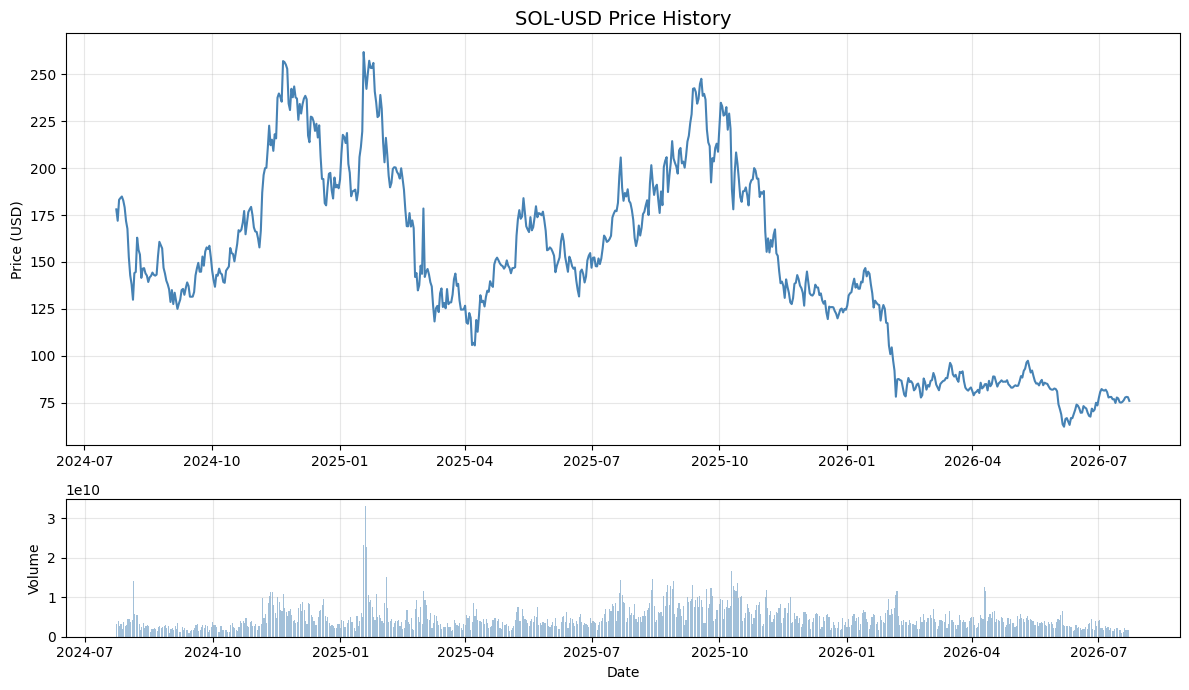

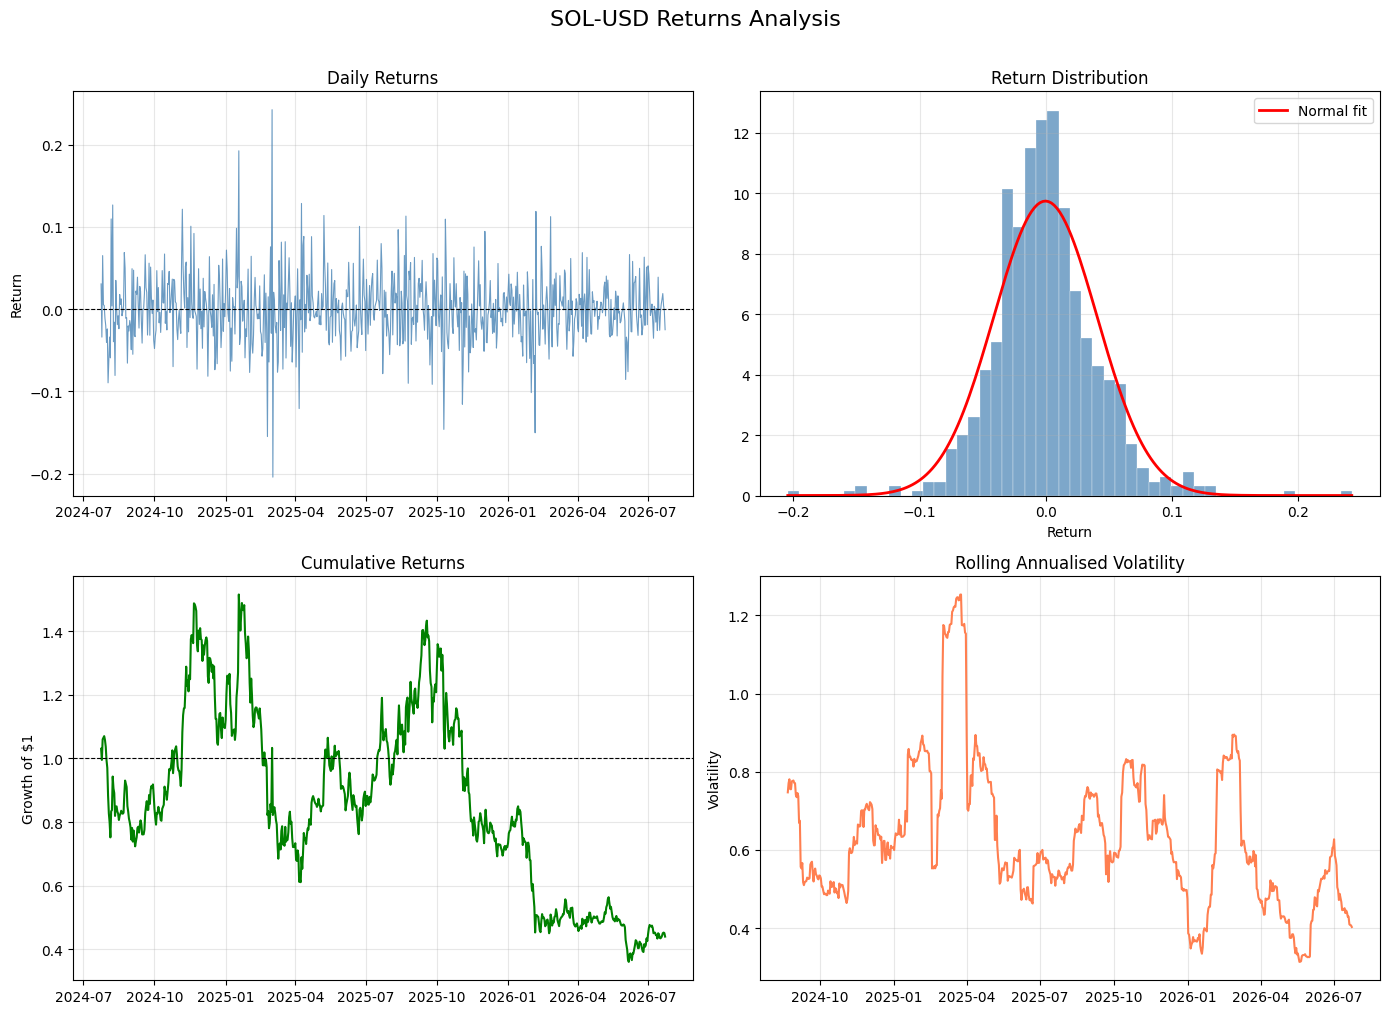

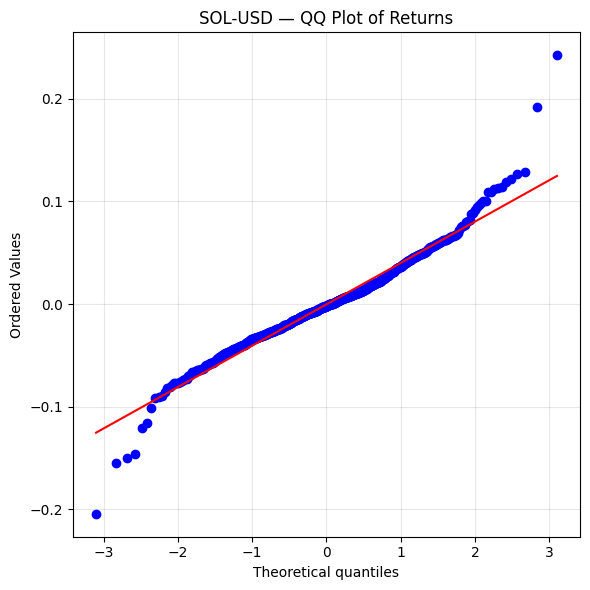

In [49]:
plot_price_history(df, ticker)
plot_returns_analysis(df, ticker)
plot_qq(df, ticker)

In [50]:
norm_test = normality_test(df)
print(f"Stastistic: {norm_test['statistic']:.4f}")
print(f"p-value: {norm_test['p_value']:.4f}")
print(f"Normal? : {norm_test['is_normal']}")

Stastistic: 79.3626
p-value: 0.0000
Normal? : False


In [51]:
tickers = [ 
    "BTC-USD"
    "SOL-USD"
    "ETH-USD"
    "AAPL"
    "SPY"
    "GLD"
]

In [52]:
from analysis import compare_assets
ranking = compare.assets(tickets, period="2y")
ranking.round(4)

ImportError: cannot import name 'compare_assets' from 'analysis' (/Users/oscarlewis/Desktop/python/trading_portfolio/project1_market_analysis/notebooks/../src/analysis.py)

In [ ]:
print("=== Asset Ranking by Sharpe Ratio ===\n")
for ticker, row in ranking.iterrows():
    print(f"{ticker:10s} | Sharpe: {float(row['sharpe_ratio']):.6.3f}" |
    f"Ann. Return: {float(row['annualised_return']):7.3f}" |
    f"Volatility: {float(row['annualised_vol']):6.3f}" |
    f"MAX DD: {float(row['max_drawdown']):7.3f}")

=== Asset Ranking by Sharpe Ratio ===



NameError: name 'ranking' is not defined